# Análise Exploratória de Dados

Este notebook carrega os dois arquivos do PublicHearingBR baixados em `challenge/dataset/`, investiga o schema real dos dados, verifica a escala do dataset e explora um sinal de verificação de alucinação que não é óbvio à primeira vista.

In [1]:
import json
import os
from pathlib import Path

import pandas as pd
import matplotlib.pyplot as plt

from experiments.common.provenance import PROJECT_DIR

os.chdir(PROJECT_DIR)

## Carregamento dos dados

In [2]:
dataset_dir = Path("dataset")
lds_path = dataset_dir / "PublicHearingBR_LDS.jsonl"
nli_path = dataset_dir / "PublicHearingBR_NLI.jsonl"

In [3]:
with open(lds_path) as f:
    lds_records = [json.loads(line) for line in f]

In [4]:
with open(nli_path) as f:
    nli_records = [json.loads(line) for line in f]

In [5]:
print(f"registros LDS: {len(lds_records)}")
print(f"registros NLI: {len(nli_records)}")

registros LDS: 206
registros NLI: 206


## O que cada arquivo realmente contém

Antes de assumir qualquer nome de campo, vale inspecionar as chaves reais dos dois arquivos.

In [6]:
sample_lds = lds_records[0]
print("chaves LDS:", list(sample_lds.keys()))
print("chaves metadados:", list(sample_lds["metadados"].keys()))
print("chaves de um envolvido:", list(sample_lds["metadados"]["envolvidos"][0].keys()))

chaves LDS: ['id', 'materia', 'metadados', 'transcricao']
chaves metadados: ['assunto', 'envolvidos']
chaves de um envolvido: ['nome', 'cargo', 'opinioes']


In [7]:
sample_nli = nli_records[0]
print("chaves NLI:", list(sample_nli.keys()))
print("chaves metadados_extraidos:", list(sample_nli["metadados_extraidos"].keys()))
envolvido_nli = sample_nli["metadados_extraidos"]["envolvidos"][0]
print("chaves de um envolvido (NLI):", list(envolvido_nli.keys()))
print("chaves de uma opiniao (NLI):", list(envolvido_nli["opinioes"][0].keys()))
print(
    "chaves de verificacao_alucinacao:",
    list(envolvido_nli["opinioes"][0]["verificacao_alucinacao"].keys()),
)

chaves NLI: ['id', 'metadados_extraidos']
chaves metadados_extraidos: ['assunto', 'envolvidos', 'tl_dr']
chaves de um envolvido (NLI): ['nome', 'cargo', 'opinioes']
chaves de uma opiniao (NLI): ['opiniao', 'chunks_proximos', 'verificacao_alucinacao']
chaves de verificacao_alucinacao: ['verificacao_manual', 'prompt_1_gpt-4o-mini-2024-07-18', 'prompt_2_gpt-4o-mini-2024-07-18', 'prompt_3_gpt-4o-mini-2024-07-18', 'prompt_1_gpt-4o-2024-08-06', 'prompt_2_gpt-4o-2024-08-06', 'prompt_3_gpt-4o-2024-08-06', 'prompt_1_deepseek-chat', 'prompt_2_deepseek-chat', 'prompt_3_deepseek-chat', 'prompt_1_sabia-3.1-2025-05-08', 'prompt_2_sabia-3.1-2025-05-08', 'prompt_3_sabia-3.1-2025-05-08']


Não há nenhum campo estruturado de data, comissão ou URL de origem: o identificador de cada registro é um `id` inteiro. O arquivo NLI não guarda o texto da transcrição nem da matéria, só a metadata extraída, e cada opinião ali vem acompanhada de uma estrutura de verificação de alucinação bem mais rica do que se poderia imaginar à primeira vista, mais sobre isso adiante.

## Estrutura de turnos de fala na transcrição

Antes de tentar separar a fala de cada participante, vale checar se a transcrição tem algum marcador de turno reconhecível, ou se é um bloco de texto corrido sem estrutura aproveitável.

In [8]:
import re

In [9]:
print(lds_records[0]["transcricao"][:600])

O SR. PRESIDENTE(Lucas Redecker. Bloco/PSDB - RS) - Muito boa tarde.

Em nome da Comissão de Relações Exteriores e de Defesa Nacional, dou as boas-vindas aos nossos convidados, que pronta e gentilmente aceitaram o convite para participar deste importante debate.

Cumprimento de forma especial todas as Deputadas e Deputados que participam desta reunião, bem como as assessorias parlamentares, os profissionais da imprensa e o público que nos acompanha presencialmente eon-linepela página da Comissão na Internet e pelo canal da Câmara dos Deputados no Youtube.

Esta audiência decorre da aprovação, 


In [10]:
turn_pattern = re.compile(r"(?:O\s+SR\.|A\s+SRA\.)\s*[A-ZÀ-Ü][^(\n]{0,60}\([^)]*\)\s*-\s")
turn_counts = [len(turn_pattern.findall(r["transcricao"])) for r in lds_records]

In [11]:
print(f"média de turnos/transcrição: {sum(turn_counts) / len(turn_counts):.1f}")
print(f"mínimo: {min(turn_counts)}, máximo: {max(turn_counts)}")
print(f"transcrições sem nenhum turno detectado: {sum(1 for c in turn_counts if c == 0)}")

média de turnos/transcrição: 50.5
mínimo: 5, máximo: 2604
transcrições sem nenhum turno detectado: 0


A transcrição segue o formato oficial de registro da Câmara: cada fala começa com `O SR.` ou `A SRA.`, seguido do nome e do partido/estado entre parênteses. Com um regex simples, as 206 transcrições têm turnos detectáveis (em média cerca de 50 por audiência), o que sugere que separar a fala por participante não exige nenhum modelo, só esse padrão de texto.

## Escala de transcrições e matérias

In [12]:
transcript_word_counts = [len(r["transcricao"].split()) for r in lds_records]
article_word_counts = [len(r["materia"].split()) for r in lds_records]

In [13]:
scale_df = pd.DataFrame(
    {
        "transcript_words": transcript_word_counts,
        "article_words": article_word_counts,
    }
)
scale_df.describe()

,transcript_words,article_words
count,206.000000,206.000000
mean,18102.087379,627.723301
std,12137.409971,160.346017
min,4437.000000,288.000000
25%,12079.250000,522.250000
50%,16424.500000,607.000000
75%,20858.750000,706.250000
max,147728.000000,1215.000000


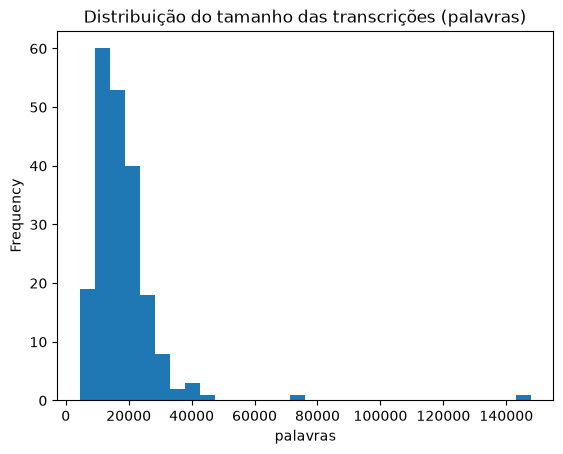

In [14]:
scale_df["transcript_words"].plot(
    kind="hist", bins=30, title="Distribuição do tamanho das transcrições (palavras)"
)
plt.xlabel("palavras")
plt.show()

As transcrições têm em média cerca de 18 mil palavras (podendo passar de 140 mil), e as matérias giram em torno de 600 a 630 palavras, uma compressão média de mais de 95%. Esses valores batem com os reportados no artigo original de Fernandes et al. (2024), o que dá confiança de que o dump do Hugging Face corresponde à versão descrita na publicação.

## Participantes e opiniões estruturadas

In [15]:
from collections import Counter

In [16]:
people_counts = [len(r["metadados"]["envolvidos"]) for r in lds_records]
opinion_counts = [
    sum(len(p["opinioes"]) for p in r["metadados"]["envolvidos"]) for r in lds_records
]

In [17]:
print(f"total de envolvidos: {sum(people_counts)}")
print(f"total de opiniões: {sum(opinion_counts)}")
print(f"média envolvidos/audiência: {sum(people_counts) / len(lds_records):.2f}")
print(f"média opiniões/audiência: {sum(opinion_counts) / len(lds_records):.2f}")

total de envolvidos: 1065
total de opiniões: 2203
média envolvidos/audiência: 5.17
média opiniões/audiência: 10.69


In [18]:
cargo_counter = Counter(
    p["cargo"] for r in lds_records for p in r["metadados"]["envolvidos"]
)
cargo_counter.most_common(10)

[('Deputada (PT-DF)', 16),
 ('Deputada (Psol-SP)', 10),
 ('Deputado (Psol-RJ)', 10),
 ('Deputado (PT-SP)', 9),
 ('Deputado (PT-BA)', 8),
 ('Deputado (PT-MG)', 7),
 ('Deputada (PT-MG)', 6),
 ('Representante do Ministério da Saúde', 6),
 ('Deputado (PSD-RJ)', 5),
 ('Deputado (PP-ES)', 5)]

Pouco mais de 5 participantes e 10 opiniões por audiência, em média, de novo alinhado com o que o artigo original reporta. Os cargos mais frequentes são dominados por deputados de diferentes partidos, o que já sugere que qualquer análise de posição/stance vai precisar lidar com uma cauda longa de cargos pouco frequentes (representantes de ministérios, entidades, especialistas).

## Conjunto NLI e verificação de alucinação

Cada opinião do arquivo NLI carrega `chunks_proximos` (os trechos recuperados) e `verificacao_alucinacao`, com uma `verificacao_manual` feita por um especialista e vários julgamentos automáticos adicionais.

In [19]:
nli_opinions = [
    opiniao
    for r in nli_records
    for p in r["metadados_extraidos"]["envolvidos"]
    for opiniao in p["opinioes"]
]
print(f"total de opiniões no conjunto NLI: {len(nli_opinions)}")

total de opiniões no conjunto NLI: 4238


In [20]:
manual_flags = [op["verificacao_alucinacao"]["verificacao_manual"] for op in nli_opinions]
hallucination_count = sum(manual_flags)
print(
    f"alucinações (manual): {hallucination_count}/{len(manual_flags)} = "
    f"{hallucination_count / len(manual_flags):.2%}"
)

alucinações (manual): 504/4238 = 11.89%


In [21]:
judge_keys = [
    key for key in nli_opinions[0]["verificacao_alucinacao"] if key != "verificacao_manual"
]
print(f"juízes automáticos disponíveis: {len(judge_keys)}")
for key in judge_keys:
    print(f"  {key}")

juízes automáticos disponíveis: 12
  prompt_1_gpt-4o-mini-2024-07-18
  prompt_2_gpt-4o-mini-2024-07-18
  prompt_3_gpt-4o-mini-2024-07-18
  prompt_1_gpt-4o-2024-08-06
  prompt_2_gpt-4o-2024-08-06
  prompt_3_gpt-4o-2024-08-06
  prompt_1_deepseek-chat
  prompt_2_deepseek-chat
  prompt_3_deepseek-chat
  prompt_1_sabia-3.1-2025-05-08
  prompt_2_sabia-3.1-2025-05-08
  prompt_3_sabia-3.1-2025-05-08


In [22]:
judge_hallucination_rate = {
    key: sum(op["verificacao_alucinacao"][key]["alucinacao"] for op in nli_opinions)
    / len(nli_opinions)
    for key in judge_keys
}
pd.Series(judge_hallucination_rate, name="taxa_alucinacao_detectada").sort_values(
    ascending=False
)

prompt_3_gpt-4o-mini-2024-07-18    0.423313
prompt_3_gpt-4o-2024-08-06         0.299670
prompt_2_gpt-4o-mini-2024-07-18    0.206465
prompt_2_gpt-4o-2024-08-06         0.205757
prompt_3_deepseek-chat             0.198915
prompt_1_gpt-4o-2024-08-06         0.120812
prompt_2_deepseek-chat             0.114677
prompt_3_sabia-3.1-2025-05-08      0.093912
prompt_1_gpt-4o-mini-2024-07-18    0.090609
prompt_2_sabia-3.1-2025-05-08      0.087305
prompt_1_deepseek-chat             0.078103
prompt_1_sabia-3.1-2025-05-08      0.072204
Name: taxa_alucinacao_detectada, dtype: float64

In [23]:
judge_agreement = {
    key: sum(
        op["verificacao_alucinacao"][key]["alucinacao"]
        == op["verificacao_alucinacao"]["verificacao_manual"]
        for op in nli_opinions
    )
    / len(nli_opinions)
    for key in judge_keys
}
pd.Series(judge_agreement, name="concordancia_com_rotulo_manual").sort_values(
    ascending=False
)

prompt_1_gpt-4o-mini-2024-07-18    0.942898
prompt_2_sabia-3.1-2025-05-08      0.927324
prompt_1_deepseek-chat             0.927088
prompt_3_sabia-3.1-2025-05-08      0.926852
prompt_1_sabia-3.1-2025-05-08      0.926380
prompt_2_deepseek-chat             0.925437
prompt_1_gpt-4o-2024-08-06         0.920245
prompt_3_deepseek-chat             0.875177
prompt_2_gpt-4o-2024-08-06         0.870694
prompt_2_gpt-4o-mini-2024-07-18    0.870458
prompt_3_gpt-4o-2024-08-06         0.797546
prompt_3_gpt-4o-mini-2024-07-18    0.677206
Name: concordancia_com_rotulo_manual, dtype: float64

A taxa de alucinação manual (cerca de 12%) confirma o que o artigo original reporta. Mais interessante é a estrutura por trás dela: cada opinião já vem julgada por 4 modelos diferentes com 3 variações de prompt cada, 12 julgamentos automáticos por opinião, além do rótulo manual. Isso é um sinal pronto, gerado por terceiros, que qualquer verificador automático de conteúdo construído sobre este dataset pode usar como ponto de comparação, sem precisar gerar seus próprios rótulos automáticos do zero.

## Alinhamento entre LDS e NLI

In [24]:
ids_match = all(l["id"] == n["id"] for l, n in zip(lds_records, nli_records))
print(f"ids alinhados 1:1 por posição: {ids_match}")

ids alinhados 1:1 por posição: True


In [25]:
same_subject_count = sum(
    1
    for l, n in zip(lds_records, nli_records)
    if l["metadados"]["assunto"] == n["metadados_extraidos"]["assunto"]
)
print(f"registros com 'assunto' idêntico entre LDS e NLI: {same_subject_count}/{len(lds_records)}")

registros com 'assunto' idêntico entre LDS e NLI: 0/206


In [26]:
example_id = 0
print("assunto (LDS):", lds_records[example_id]["metadados"]["assunto"])
print("assunto (NLI):", nli_records[example_id]["metadados_extraidos"]["assunto"])

assunto (LDS): Acusações de censura contra Alexandre de Moraes por exigir bloqueio de contas na rede social X
assunto (NLI): Discussão sobre censura e liberdade de expressão no Brasil, com foco nos Twitter Files e as ações do STF.


O `assunto` nunca é idêntico entre os dois arquivos, mesmo para a mesma audiência: cada arquivo passou por uma extração independente sobre a mesma audiência, não é um metadado canônico único. Vale investigar mais fundo se as opiniões em si vêm da mesma fonte.

### As opiniões do LDS e do NLI são o mesmo dado?

Se fossem, as opiniões de uma audiência deveriam aparecer, ao menos em boa parte, nos dois arquivos.

In [27]:
sample_hearing_lds = lds_records[0]
sample_hearing_nli = nli_records[0]

lds_opinion_texts = {
    opiniao.strip()
    for pessoa in sample_hearing_lds["metadados"]["envolvidos"]
    for opiniao in pessoa["opinioes"]
}
nli_opinion_texts = [
    opiniao["opiniao"].strip()
    for pessoa in sample_hearing_nli["metadados_extraidos"]["envolvidos"]
    for opiniao in pessoa["opinioes"]
]

In [28]:
exact_matches = sum(1 for texto in nli_opinion_texts if texto in lds_opinion_texts)
print(f"opiniões no LDS: {len(lds_opinion_texts)}")
print(f"opiniões no NLI: {len(nli_opinion_texts)}")
print(f"correspondências exatas: {exact_matches}")

opiniões no LDS: 26
opiniões no NLI: 18
correspondências exatas: 0


In [29]:
print("exemplo de opinião NLI:", nli_opinion_texts[0])
print()
print("exemplo de opinião LDS:", next(iter(lds_opinion_texts)))

exemplo de opinião NLI: Destacou a importância da audiência para discutir a censura e a liberdade de expressão no Brasil.

exemplo de opinião LDS: Criticou o Projeto de Lei 2630/20, conhecido como PL das Fake News, e defendeu o Marco Civil da Internet.


Zero correspondências exatas, e os textos têm estilos bem diferentes: a opinião do NLI é uma síntese curta, a do LDS costuma incluir citação direta. São pipelines de extração diferentes, não o mesmo dado com mais campos.

### Os chunks_proximos do NLI vêm mesmo da transcrição?

O NLI não guarda `transcricao`, mas cada opinião vem com trechos (`chunks_proximos`) que deveriam ter sido retirados dela. Isso dá para conferir cruzando com o LDS pelo `id`.

In [30]:
def normalize_whitespace(text):
    return re.sub(r"\s+", " ", text).strip()

In [31]:
transcript_normalized = normalize_whitespace(sample_hearing_lds["transcricao"])

chunks = [
    chunk
    for pessoa in sample_hearing_nli["metadados_extraidos"]["envolvidos"]
    for opiniao in pessoa["opinioes"]
    for chunk in opiniao["chunks_proximos"]
]
chunks_found = sum(
    1 for chunk in chunks if normalize_whitespace(chunk)[:150] in transcript_normalized
)
print(f"chunks encontrados na transcrição: {chunks_found}/{len(chunks)}")

chunks encontrados na transcrição: 64/72


A maior parte dos trechos aparece, literalmente, dentro da transcrição do LDS (normalizando só espaços em branco). O NLI entrega evidência real e localizável, mesmo sem vir com um offset explícito de início/fim.

## Viabilidade de extrair data e comissão do texto livre

In [32]:
import re

In [33]:
date_pattern = re.compile(r"\b\d{2}/\d{2}/\d{4}\b")
records_with_date = sum(1 for r in lds_records if date_pattern.search(r["materia"]))
print(f"registros com uma data dd/mm/aaaa na matéria: {records_with_date}/{len(lds_records)}")

registros com uma data dd/mm/aaaa na matéria: 206/206


In [34]:
committee_pattern = re.compile(r"Comiss[ãa]o[^\n.]{0,80}")
committee_samples = [
    match.group(0)
    for r in lds_records[:5]
    if (match := committee_pattern.search(r["materia"]))
]
committee_samples

['Comissão de Relações Exteriores e de Defesa Nacional da Câmara dos Deputados acusaram o ',
 'Comissão de Minas e Energia, deputado Rodrigo de Castro (União-MG), questionou sobre o \xa0',
 'Comissão de Trabalho da Câmara dos Deputados, a fim de apresentar as prioridades para es',
 'Comissão de Comunicação da Câmara dos Deputados e reconheceu que a falta de energia elét',
 'Comissão de Defesa dos Direitos das Pessoas com Deficiência da Câmara dos Deputados nest']

Data e comissão são extraíveis por heurística/regex a partir do texto livre da matéria, mas isso pede validação, já que mais de uma data ou comissão pode aparecer no corpo do texto antes de virar base confiável para qualquer análise temporal ou institucional.

## Conclusões

A escala do dataset (206 audiências, transcrições longas com forte compressão nas matérias, ~5 participantes e ~11 opiniões por audiência) e a taxa de alucinação manual (~12%) batem com o artigo original: o dump do Hugging Face corresponde à versão publicada.

Nenhum dos dois arquivos tem data, comissão ou URL como campo estruturado; essas informações só existem como texto livre e precisam ser extraídas (e validadas) se forem necessárias. O identificador é um `id` inteiro simples.

LDS e NLI não são o mesmo dado com mais campos: são dois pipelines de extração diferentes sobre fontes diferentes (matéria e transcrição), por isso o `assunto` e as opiniões nunca coincidem entre eles. Ainda assim, os `chunks_proximos` do NLI são excertos reais da transcrição do LDS, uma evidência textual já pronta para uso.

A transcrição também tem uma estrutura de turno de fala bem definida e detectável por regex simples (`O SR.`/`A SRA. NOME(PARTIDO) - fala`), presente nas 206 audiências, o que abre caminho para segmentar a fala por participante sem depender de nenhum modelo.

Por fim, o conjunto de 12 julgamentos automáticos de alucinação já publicados junto com a verificação manual é um sinal de terceiros pronto para uso, com taxas de acerto e concordância bem diferentes entre modelos e prompts, que vale a pena explorar antes de construir qualquer verificador do zero.